# Mini Project 1



# Student Performance Prediction Using Multiple Linear Regression

### Submitted By
Simra Arfeen


### Objective
The objective of this project is to predict students' exam scores based on various academic, personal, and lifestyle factors. A Multiple Linear Regression model is used to analyze the relationship between these factors and student performance.

## Project Overview

Student performance is influenced by several factors such as study habits, attendance, parental involvement, sleep hours, and previous academic records. Understanding how these factors affect exam scores can help educators and students make informed decisions to improve learning outcomes.

In this project, a Multiple Linear Regression model is developed to predict students' exam scores using a real-world dataset. The project includes data exploration, preprocessing, visualization, model training, prediction, and performance evaluation using standard regression metrics.

## Project Objective

The main objectives of this project are:

- To understand the student performance dataset.
- To clean and preprocess the data for analysis.
- To visualize important relationships between different variables.
- To build a Multiple Linear Regression model.
- To predict students' exam scores accurately.
- To evaluate the model using regression performance metrics.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

## 1. Preview of the Dataset

Before starting the analysis, let's check the first few records to get familiar with the dataset.

In [5]:
import pandas as pd

# Assuming the dataset is in a CSV file named 'student_performance.csv'
data = pd.read_csv('StudentPerformanceFactors.csv')

print("=" * 60)
print("FIRST 5 RECORDS")
print("=" * 60)

data.head().T

FIRST 5 RECORDS


,0,1,2,3,4
Hours_Studied,23,19,24,29,19
Attendance,84,64,98,89,92
Parental_Involvement,Low,Low,Medium,Low,Medium
Access_to_Resources,High,Medium,Medium,Medium,Medium
Extracurricular_Activities,No,No,Yes,Yes,Yes
Sleep_Hours,7,8,7,8,6
Previous_Scores,73,59,91,98,65
Motivation_Level,Low,Low,Medium,Medium,Medium
Internet_Access,Yes,Yes,Yes,Yes,Yes
Tutoring_Sessions,0,2,2,1,3


## 2. Preview of the Last 5 Records

Now let's check the last few records to get a complete view of the dataset.

In [ ]:
print("=" * 60)
print("LAST 5 RECORDS")
print("=" * 60)

data.tail()

LAST 5 RECORDS


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
6602,25,69,High,Medium,No,7,76,Medium,Yes,1,High,Medium,Public,Positive,2,No,High School,Near,Female,68
6603,23,76,High,Medium,No,8,81,Medium,Yes,3,Low,High,Public,Positive,2,No,High School,Near,Female,69
6604,20,90,Medium,Low,Yes,6,65,Low,Yes,3,Low,Medium,Public,Negative,2,No,Postgraduate,Near,Female,68
6605,10,86,High,High,Yes,6,91,High,Yes,2,Low,Medium,Private,Positive,3,No,High School,Far,Female,68
6606,15,67,Medium,Low,Yes,9,94,Medium,Yes,0,Medium,Medium,Public,Positive,4,No,Postgraduate,Near,Male,64


## 3. Dataset Shape

Let's check the shape of the dataset to see how many rows and columns it contains.

In [ ]:
print("=" * 60)
print("DATASET SHAPE")
print("=" * 60)

print(data.shape)

DATASET SHAPE
(6607, 20)


## 4. Column Names

Let's display all the column names to understand what information is available in the dataset.

In [ ]:
print("=" * 60)
print("COLUMN NAMES")
print("=" * 60)

print(data.columns)

COLUMN NAMES
Index(['Hours_Studied', 'Attendance', 'Parental_Involvement',
       'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours',
       'Previous_Scores', 'Motivation_Level', 'Internet_Access',
       'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type',
       'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities',
       'Parental_Education_Level', 'Distance_from_Home', 'Gender',
       'Exam_Score'],
      dtype='object')


## 5. Dataset Information

Let's check the dataset information to understand the data types of each column and see if there are any missing values.

In [ ]:
print("=" * 60)
print("DATASET INFORMATION")
print("=" * 60)

data.info()

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              

## 6. Statistical Summary

Let's look at the summary statistics of the numerical columns to get a better understanding of the data, including the average, minimum, maximum, and overall distribution of the values.

In [ ]:
print("=" * 60)
print("STATISTICAL SUMMARY")
print("=" * 60)

data.describe()

STATISTICAL SUMMARY


,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


## 7. Missing Values

Let's check if there are any missing values in the dataset. Identifying missing data helps us decide whether any cleaning or preprocessing is needed before training the model.

In [ ]:
print("=" * 60)
print("MISSING VALUES")
print("=" * 60)

data.isnull().sum()

MISSING VALUES


,0
Hours_Studied,0
Attendance,0
Parental_Involvement,0
Access_to_Resources,0
Extracurricular_Activities,0
Sleep_Hours,0
Previous_Scores,0
Motivation_Level,0
Internet_Access,0
Tutoring_Sessions,0


## 8. Duplicate Records

Let's check whether the dataset contains any duplicate records. Removing duplicates, if any, helps improve the quality of the data before training the model.

In [ ]:
print("=" * 60)
print("DUPLICATE RECORDS")
print("=" * 60)

print(data.duplicated().sum())

DUPLICATE RECORDS
0


# Data Preprocessing

Before training the machine learning model, the dataset needs to be prepared. In this step, we'll separate the input features from the target variable and convert the categorical columns into numerical values using one-hot encoding so that the model can work with the data.

## 1. Separate Input Features and Target Variable

The dataset is divided into input features (X) and the target variable (y). All columns except `Exam_Score` are used as input features, while `Exam_Score` is used as the target variable for prediction.

In [ ]:
# Input Features
X = data.drop("Exam_Score", axis=1)

# Target Variable
y = data["Exam_Score"]

print("Input Features Shape:", X.shape)
print("Target Variable Shape:", y.shape)

Input Features Shape: (6607, 19)
Target Variable Shape: (6607,)


## 2. Convert Categorical Variables into Numerical Values

Since machine learning models work with numerical data, the categorical columns are converted into numerical values using one-hot encoding. This makes the data suitable for training the Linear Regression model.

In [ ]:
X = pd.get_dummies(X, drop_first=True)

print("Shape After Encoding:", X.shape)

Shape After Encoding: (6607, 27)


## 3. Verify Processed Features

After converting the categorical columns into numerical values, let's check the processed dataset to make sure the transformation was applied correctly.

In [ ]:
X.head()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Parental_Involvement_Low,Parental_Involvement_Medium,Access_to_Resources_Low,Access_to_Resources_Medium,...,Teacher_Quality_Medium,School_Type_Public,Peer_Influence_Neutral,Peer_Influence_Positive,Learning_Disabilities_Yes,Parental_Education_Level_High School,Parental_Education_Level_Postgraduate,Distance_from_Home_Moderate,Distance_from_Home_Near,Gender_Male
0,23,84,7,73,0,3,True,False,False,False,...,True,True,False,True,False,True,False,False,True,True
1,19,64,8,59,2,4,True,False,False,True,...,True,True,False,False,False,False,False,True,False,False
2,24,98,7,91,2,4,False,True,False,True,...,True,True,True,False,False,False,True,False,True,True
3,29,89,8,98,1,4,True,False,False,True,...,True,True,False,False,False,True,False,True,False,True
4,19,92,6,65,3,4,False,True,False,True,...,False,True,True,False,False,False,False,False,True,False


## 4. Check Data Types After Encoding

After encoding the categorical features, let's verify the data types to make sure all the input features are in a format that the machine learning model can use.

In [ ]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 27 columns):
 #   Column                                 Non-Null Count  Dtype
---  ------                                 --------------  -----
 0   Hours_Studied                          6607 non-null   int64
 1   Attendance                             6607 non-null   int64
 2   Sleep_Hours                            6607 non-null   int64
 3   Previous_Scores                        6607 non-null   int64
 4   Tutoring_Sessions                      6607 non-null   int64
 5   Physical_Activity                      6607 non-null   int64
 6   Parental_Involvement_Low               6607 non-null   bool 
 7   Parental_Involvement_Medium            6607 non-null   bool 
 8   Access_to_Resources_Low                6607 non-null   bool 
 9   Access_to_Resources_Medium             6607 non-null   bool 
 10  Extracurricular_Activities_Yes         6607 non-null   bool 
 11  Motivation_Level_Low          

# Train-Test Split

Before training the model, the dataset is divided into training and testing sets. The training data is used to build the model, while the testing data is used to evaluate how well it performs on unseen data.

##1. Split the Dataset

The dataset is split into training and testing sets using an 80:20 ratio. This helps evaluate the model's performance on data it has not seen during training.

In [ ]:
# Split dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Features Shape :", X_train.shape)
print("Testing Features Shape  :", X_test.shape)
print("Training Target Shape   :", y_train.shape)
print("Testing Target Shape    :", y_test.shape)

Training Features Shape : (5285, 27)
Testing Features Shape  : (1322, 27)
Training Target Shape   : (5285,)
Testing Target Shape    : (1322,)


##2. Verify the Training and Testing Data

Let's check the shapes of the training and testing datasets to ensure the data has been split correctly.

In [ ]:
print("Training Data")
display(X_train.head())

print("Testing Data")
display(X_test.head())

Training Data


,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Parental_Involvement_Low,Parental_Involvement_Medium,Access_to_Resources_Low,Access_to_Resources_Medium,...,Teacher_Quality_Medium,School_Type_Public,Peer_Influence_Neutral,Peer_Influence_Positive,Learning_Disabilities_Yes,Parental_Education_Level_High School,Parental_Education_Level_Postgraduate,Distance_from_Home_Moderate,Distance_from_Home_Near,Gender_Male
5810,27,79,8,63,2,5,True,False,False,False,...,True,True,False,False,False,False,False,True,False,False
1268,16,86,7,94,2,3,False,False,False,True,...,False,True,True,False,False,True,False,True,False,False
414,22,87,8,83,1,1,True,False,False,True,...,True,True,True,False,False,False,False,False,False,True
4745,18,100,10,86,1,3,False,False,False,True,...,True,True,True,False,False,True,False,False,True,True
654,35,78,10,99,1,2,False,False,True,False,...,True,False,False,True,False,True,False,False,True,True


Testing Data


,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Parental_Involvement_Low,Parental_Involvement_Medium,Access_to_Resources_Low,Access_to_Resources_Medium,...,Teacher_Quality_Medium,School_Type_Public,Peer_Influence_Neutral,Peer_Influence_Positive,Learning_Disabilities_Yes,Parental_Education_Level_High School,Parental_Education_Level_Postgraduate,Distance_from_Home_Moderate,Distance_from_Home_Near,Gender_Male
743,20,71,7,87,1,5,False,True,True,False,...,True,True,False,False,False,True,False,False,True,True
5551,22,71,7,98,2,2,False,True,True,False,...,False,True,True,False,False,True,False,True,False,False
3442,21,91,6,53,1,3,False,False,False,True,...,True,True,False,True,False,False,True,False,True,False
6571,12,91,8,81,0,4,False,True,True,False,...,False,True,False,True,False,True,False,True,False,True
4204,21,63,8,95,2,5,True,False,False,False,...,True,True,True,False,False,True,False,False,True,True


##3. Verify the Target Variables

We'll also verify the target variables to confirm that the training and testing labels have been separated correctly.

In [ ]:
print("Training Target")
display(y_train.head())

print("Testing Target")
display(y_test.head())

Training Target


,Exam_Score
5810,69
1268,69
414,66
4745,72
654,72


Testing Target


,Exam_Score
743,65
5551,65
3442,71
6571,64
4204,66


# Model Building

Now that the data is ready, the next step is to build a Linear Regression model using the training dataset.

## 1. Create the Linear Regression Model

A Linear Regression model is created to learn the relationship between the input features and the exam scores.

In [ ]:
# Create Linear Regression Model

model = LinearRegression()

print("Linear Regression Model Created Successfully.")

Linear Regression Model Created Successfully.


## 2. Train the Model

The model is trained using the training dataset so it can learn patterns and make predictions on new data.

In [ ]:
# Train the model

model.fit(X_train, y_train)

print("Model Trained Successfully.")

Model Trained Successfully.


## 3. Display the Model Intercept

Let's check the intercept value calculated by the Linear Regression model.

In [ ]:
print("Intercept:")

print(model.intercept_)

Intercept:
41.9328207228083


## 4. Display Feature Coefficients

The feature coefficients show how each input feature influences the predicted exam score.

In [ ]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients

,Feature,Coefficient
0,Hours_Studied,0.292928
1,Attendance,0.198771
2,Sleep_Hours,-0.012356
3,Previous_Scores,0.048995
4,Tutoring_Sessions,0.508731
5,Physical_Activity,0.191672
6,Parental_Involvement_Low,-2.002509
7,Parental_Involvement_Medium,-1.072646
8,Access_to_Resources_Low,-2.091793
9,Access_to_Resources_Medium,-1.032266


## 5. Sort Feature Importance

Sorting the coefficients makes it easier to identify which features have the greatest impact on the predictions.

In [ ]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
}).sort_values(
    by="Coefficient",
    key=abs,
    ascending=False
)

display(coefficients)

,Feature,Coefficient
8,Access_to_Resources_Low,-2.091793
6,Parental_Involvement_Low,-2.002509
14,Family_Income_Low,-1.106433
7,Parental_Involvement_Medium,-1.072646
11,Motivation_Level_Low,-1.046229
20,Peer_Influence_Positive,1.045440
9,Access_to_Resources_Medium,-1.032266
16,Teacher_Quality_Low,-0.993999
13,Internet_Access_Yes,0.956229
21,Learning_Disabilities_Yes,-0.861118


# Model Prediction & Evaluation

After training the model, we'll use it to make predictions and evaluate how accurately it performs.

## 1. Predict Exam Scores

The trained model is used to predict exam scores for the testing dataset.

In [ ]:
# Predict exam scores

predicted_scores = model.predict(X_test)

print("Prediction Completed Successfully.")

Prediction Completed Successfully.


##2.  Compare Actual and Predicted Scores

Comparing the actual and predicted values helps us understand how closely the model's predictions match the real exam scores.

In [ ]:
comparison = pd.DataFrame({
    "Actual Score": y_test.values,
    "Predicted Score": predicted_scores
})

comparison.head(10)

,Actual Score,Predicted Score
0,65,64.541818
1,65,65.237684
2,71,71.536760
3,64,64.269738
4,66,66.526773
5,66,66.623520
6,72,72.429805
7,66,66.474664
8,70,69.973029
9,70,70.113235


## 3. Calculate Evaluation Metrics

We'll calculate different evaluation metrics to measure the model's overall performance.

In [ ]:
mae = mean_absolute_error(y_test, predicted_scores)

mse = mean_squared_error(y_test, predicted_scores)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, predicted_scores)

## 4. Display Evaluation Results

The evaluation results provide an overview of how well the Linear Regression model performs on the testing data.

In [ ]:
print("=" * 60)
print("MODEL PERFORMANCE")
print("=" * 60)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

MODEL PERFORMANCE
Mean Absolute Error (MAE): 0.45
Mean Squared Error (MSE): 3.26
Root Mean Squared Error (RMSE): 1.80
R² Score: 0.7696


## Interpretation of Results

Based on the evaluation metrics, we can assess the accuracy of the model and understand its overall performance.

# Data Visualization

Visualizations make it easier to understand the data, evaluate the model's performance, and identify important patterns.

## 1. Distribution of Exam Scores

Let's visualize the distribution of exam scores to see how the values are spread across the dataset.

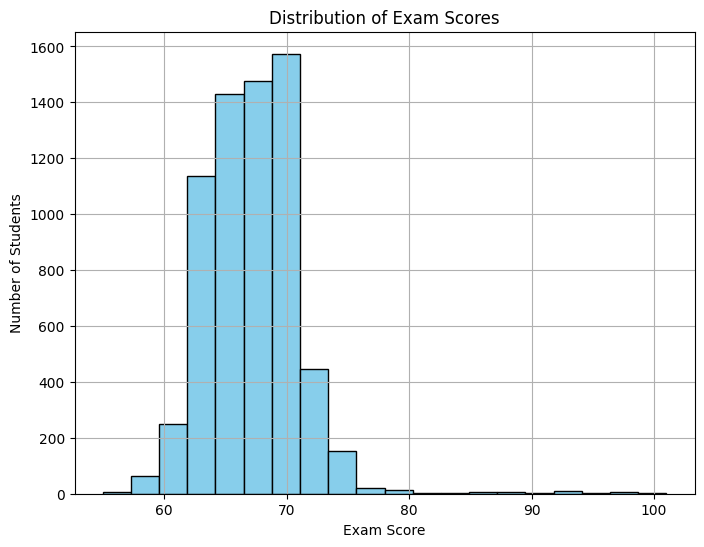

In [ ]:
plt.figure(figsize=(8,6))

plt.hist(
    data["Exam_Score"],
    bins=20,
    color="skyblue",
    edgecolor="black"
)

plt.title("Distribution of Exam Scores")
plt.xlabel("Exam Score")
plt.ylabel("Number of Students")
plt.grid(True)

plt.show()

## 2. Actual vs Predicted Exam Scores

This plot compares the actual exam scores with the predicted values to show how closely the model performs.

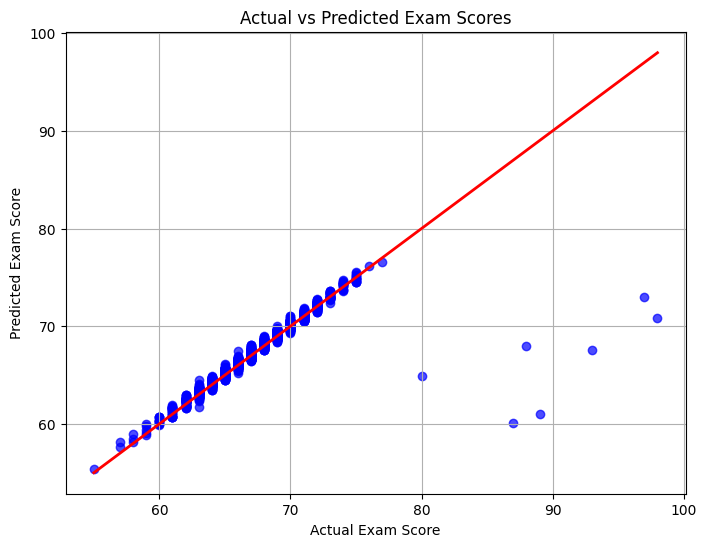

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    predicted_scores,
    color="blue",
    alpha=0.7
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2
)

plt.title("Actual vs Predicted Exam Scores")
plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.grid(True)

plt.show()

## 3. Feature Importance

The feature importance chart highlights which factors have the strongest influence on exam score predictions.

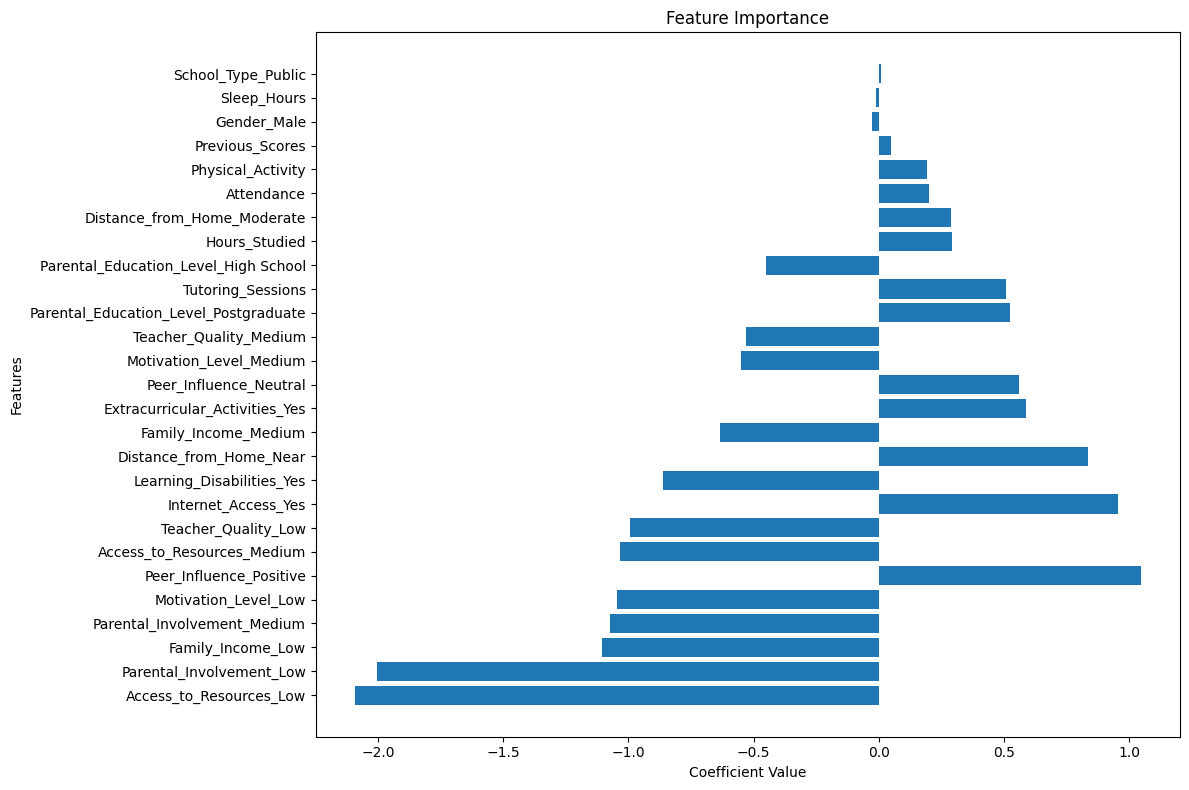

In [ ]:
plt.figure(figsize=(12,8))

plt.barh(
    coefficients["Feature"],
    coefficients["Coefficient"]
)

plt.title("Feature Importance")
plt.xlabel("Coefficient Value")
plt.ylabel("Features")

plt.tight_layout()

plt.show()

## 4. Residual Plot

The residual plot helps identify prediction errors and shows how well the model fits the data.

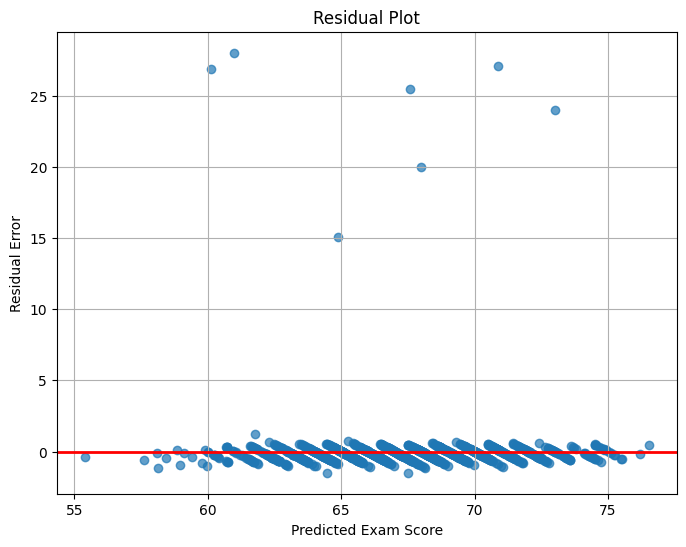

In [ ]:
residuals = y_test - predicted_scores

plt.figure(figsize=(8,6))

plt.scatter(
    predicted_scores,
    residuals,
    alpha=0.7
)

plt.axhline(
    y=0,
    color="red",
    linewidth=2
)

plt.title("Residual Plot")
plt.xlabel("Predicted Exam Score")
plt.ylabel("Residual Error")
plt.grid(True)

plt.show()

# Prediction for a New Student

Finally, we'll use the trained model to predict the exam score for a sample student using new input data.

## 1. Predict Exam Score for a Sample Student

The model predicts the expected exam score based on the sample student's information.

In [ ]:
# Select the first student's features

sample_student = X.iloc[[0]]

# Predict Exam Score

predicted_score = model.predict(sample_student)

print("Predicted Exam Score:", round(predicted_score[0], 2))

Predicted Exam Score: 67.12


## 2. Compare Actual and Predicted Score

Comparing the predicted score with the actual value gives a practical example of the model's performance.

In [ ]:
actual_score = y.iloc[0]

print("Actual Exam Score    :", actual_score)
print("Predicted Exam Score :", round(predicted_score[0], 2))

Actual Exam Score    : 67
Predicted Exam Score : 67.12


# Conclusion

In this project, a Linear Regression model was developed to predict students' exam scores using different academic and personal factors. The model was trained, evaluated, and tested successfully. The results show that machine learning can be used to estimate student performance with good accuracy based on the available data.

# References

- Kaggle Dataset: Student Performance Factors
- Python Documentation
- Pandas Documentation
- NumPy Documentation
- Matplotlib Documentation
- Scikit-learn Documentation

# Future Scope

The project can be improved by testing different machine learning algorithms such as Decision Tree, Random Forest, or XGBoost. Additional features and larger datasets may also help improve prediction accuracy in future versions.